In [ ]:
import os
import json
from dotenv import load_dotenv
load_dotenv()

from typing import Annotated, Any, Union, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

/Users/abinashpant/Codes/projects/agents_basesetup/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

llm = ChatGoogleGenerativeAI(
    model='gemini-2.0-flash-exp',
    api_key=os.getenv('GEMINI_API_KEY')
)

graph_builder = StateGraph(State)

In [3]:
# This is placeholder function for testing and visualizing, it'll be replaced by llama-agent agent in actual src
def llama_agent(question: str) -> str:
    """
    Handles knowledge queries by summarizing the input question.
    """
    # Use Gemini to summarize the input question
    prompt = f"Answer the following  in one or two sentences:\n\n{question}"
    response = llm.invoke(prompt)
    return response.content

# Other math functions as tools
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def subtract(a: int, b: int) -> int:
    """Subtracts b from a.

    Args:
        a: first int (minuend)
        b: second int (subtrahend)
    """
    return a - b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

math_tools = [add, subtract, multiply, divide]
llm_with_math_tools = llm.bind_tools(math_tools)

In [4]:
# Classifying conditions

def math_tools_condition(
    state: Union[list[AnyMessage], dict[str, Any], BaseModel],
    messages_key: str = "messages",
) -> Literal["requires_math_tools", "no_tool_required"]:
    
    if isinstance(state, list):
        ai_message = state[-1]
    elif isinstance(state, dict) and (messages := state.get(messages_key, [])):
        ai_message = messages[-1]
    elif messages := getattr(state, messages_key, []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "requires_math_tools"
    return "no_tool_required"


def query_condition(
    state: Union[list[AnyMessage], dict[str, Any], BaseModel],
    messages_key: str = "messages",
) -> Literal["tools", "__end__"]:
    
    if isinstance(state, list):
        query = state[-1]
    elif isinstance(state, dict) and (messages := state.get(messages_key, [])):
        query = messages[-1]
    elif messages := getattr(state, messages_key, []):
        query = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    
    class RouteQuery(BaseModel):
        """
        Route user query to math_query or knowledge_query.
        """

        datasource: Literal["math_query", "knowledge_query"] = Field(
            ..., description="Route to math_query or knowledge_query."
        )

    llm = ChatGoogleGenerativeAI(
        model='gemini-2.0-flash-exp',
        api_key=os.getenv('GEMINI_API_KEY')
    )

    system_prompt = """
    You are an expert AI for classifying the user query.
    Classify the following query into one of the following categories:
    1. math_query, for any query that requires solving some mathematical expression 
    2. knowledge_query, if the question that requires some knowledge other than math
    """
    route_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            ("human", "Classify the following query: {query}"),
        ]
    )
    
    structured_llm_router = llm.with_structured_output(RouteQuery)
    question_router = route_prompt | structured_llm_router
    
    response = question_router.invoke({"query": query})
    
    if response.datasource == "math_query" or response.datasource == 'knowledge_query':
        return response.datasource
    else:
        raise ValueError(f"Unknown datasource: {response.datasource}")

In [5]:
# Build graph
def get_query(state:State):
    return {"messages": state['messages']}

def math_ai(state: State):
    return {"messages": [llm_with_math_tools.invoke(state["messages"])]}

# Update llama_agent_ai to use the summarizer
def llama_agent_ai(state: State):
    """
    Processes knowledge queries using the summarizer.
    """
    last_message = state['messages'][-1].content
    summary = llama_agent(last_message)
    return {"messages": [summary]}


# Reset the graph builder
graph_builder = StateGraph(State)

# Add nodes to the graph
graph_builder.add_node("get_query", get_query)
graph_builder.add_node("Question_answering", llama_agent_ai)
graph_builder.add_node("math_operation", math_ai)
graph_builder.add_node("math_tools", ToolNode(math_tools))

# Add edges to the graph
graph_builder.add_edge(START, "get_query")
graph_builder.add_conditional_edges(
    "get_query",
    query_condition,
    {
        'knowledge_query': 'Question_answering',
        'math_query': 'math_operation',
    }
)
graph_builder.add_conditional_edges(
    "math_operation",
    math_tools_condition,
    {
        'requires_math_tools': 'math_tools',
        'no_tool_required': END
    }
)
graph_builder.add_edge("math_tools", "math_operation")
graph_builder.add_edge('Question_answering', END)

# Compile the graph
graph = graph_builder.compile()

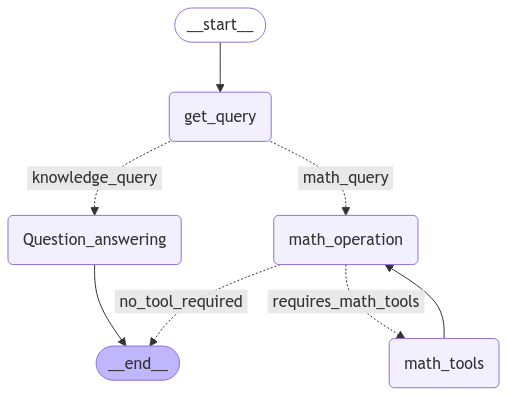

In [6]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
memory = MemorySaver()
graph_memory = graph_builder.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "1"}}

In [33]:
from IPython.display import clear_output

while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    clear_output(wait=True)
    messages = graph_memory.invoke({"messages": [HumanMessage(content=user_input)]},config)
    for m in messages['messages']:
        m.pretty_print()

================================ Human Message =================================

add 5 and 6
================================== Ai Message ==================================

I am able to subtract, multiply, and divide, but not add. Would you like to subtract, multiply, or divide 5 and 6?
Goodbye!
